mu_test: -6276.0
mu_recovered: 8822.79214878652
error: 15098.79214878652


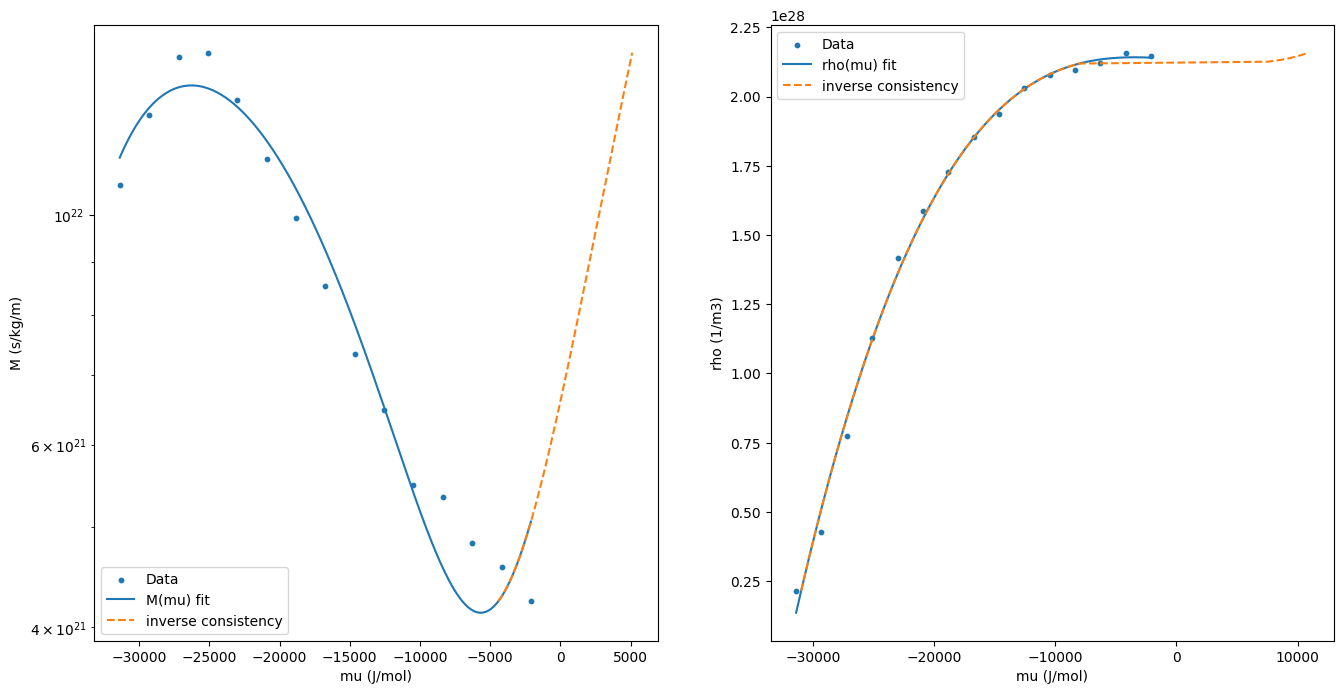

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Define some constants
volume = 4e-9 * 4e-9 * 2e-9 # m3
area = 4e-9 * 2e-9 # m2
m = 40e-3 # mass particle in kg/mol
Na = 6.022e23 # Avogadro
kcal_to_j = 4184.0 # Convert factor

degree = 3 # Degree for polynomial fit
# WARNING: the analytical inversion functions (invert_poly2, mu_from_rho_analytical)
# are hardcoded for degree=2 only. If degree is changed, these must be replaced
# by a numerical root-finding approach (e.g. scipy.optimize.brentq).

f0_real = 0.01 # force applied on each particle kcal/mol/A
f0_SI = f0_real * kcal_to_j * 1e10 / Na # N

# Load MD data

md_data = np.loadtxt("MD/number_and_v_vs_mu.dat")
mu_real, number, v_real = md_data.T # kcal/mol, 0, A/fs

# Quantities in SI units
mu_SI = mu_real * kcal_to_j
v_SI = v_real * 1e-10/1e-15
rho_SI = number/volume # m-3
total_force = rho_SI * f0_SI * volume # N
total_flux = rho_SI * v_SI * area # 1 / s
M_SI = total_flux / total_force # transport coefficient in 1/s/N = s / kg / m

# Fits
degreeM = 3
coeffs_M_vs_mu = np.polyfit(mu_SI, M_SI, degreeM)
degreeR = 3
coeffs_rho_vs_mu = np.polyfit(mu_SI, rho_SI, degreeR)

# Save fitting paramters
with open("M_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_M_vs_mu:
        f.write(f"{c}\n")

with open("rho_vs_mu_fit.txt", "w") as f:
    f.write(f"{degree}\n")
    for c in coeffs_rho_vs_mu:
        f.write(f"{c}\n")

# To test the procedure
poly_K_vs_mu = np.poly1d(coeffs_M_vs_mu)
poly_rho_vs_mu = np.poly1d(coeffs_rho_vs_mu)

coeffs = coeffs_rho_vs_mu  # [a, b, c]
a, b, c, d = coeffs

# Analytical inverses using coefficients from rho_vs_mu and M_vs_mu
def invert_poly2(y, coeffs, branch="+"):
    a, b, c = coeffs
    discriminant = b**2 - 4*a*(c - y)
    if branch == "+":
        return (-b + np.sqrt(discriminant)) / (2*a)
    else:
        return (-b - np.sqrt(discriminant)) / (2*a)

def invert_poly3(y, coeffs, mu_ref=None):
    """
    Scalar version: solves a*x^3 + b*x^2 + c*x + (d - y) = 0
    Returns the real root closest to mu_ref if provided, else the largest.
    """
    a, b, c, d = coeffs
    roots = np.roots([a, b, c, d - y])
    real_roots = roots[np.abs(roots.imag) < 1e-10].real
    if len(real_roots) == 0:
        return np.nan
    if mu_ref is not None:
        return real_roots[np.argmin(np.abs(real_roots - mu_ref))]
    return np.max(real_roots)

# Vectorized version
def invert_poly3_vec(y_array, coeffs, mu_ref=None):
    return np.array([invert_poly3(yi, coeffs, mu_ref) for yi in y_array])

mu_test = mu_SI[-3]
rho = poly_rho_vs_mu(mu_test)
mu_recovered = invert_poly3(rho, coeffs_rho_vs_mu)
print("mu_test:", mu_test)
print("mu_recovered:", mu_recovered)
print("error:", mu_recovered - mu_test)

# Grids
mu_grid  = np.linspace(min(mu_SI), max(mu_SI), 300)
M_grid   = np.linspace(min(M_SI),  max(M_SI),  300)
rho_grid = np.linspace(min(rho_SI), max(rho_SI), 300)

# Forward fits
M_fit   = poly_K_vs_mu(mu_grid)
rho_fit = poly_rho_vs_mu(mu_grid)

# M consistency
if degreeM == 2:
    mu_from_M = invert_poly2(M_grid, coeffs_M_vs_mu, branch = "-")
else:
    mu_from_M = invert_poly3_vec(M_grid, coeffs_M_vs_mu)
M_back    = poly_K_vs_mu(mu_from_M)

# rho consistency
if degreeR == 2:
    mu_from_rho = invert_poly2(rho_grid, coeffs_rho_vs_mu)
else:
    mu_from_rho = invert_poly3_vec(rho_grid, coeffs_rho_vs_mu)
rho_back    = poly_rho_vs_mu(mu_from_rho)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.scatter(mu_SI, M_SI, s=10, label="Data")
plt.plot(mu_grid, M_fit, label="M(mu) fit")
plt.plot(mu_from_M, M_back, "--", label="inverse consistency")
plt.xlabel("mu (J/mol)")
plt.ylabel("M (s/kg/m)")
plt.yscale("log")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(mu_SI, rho_SI, s=10, label="Data")
plt.plot(mu_grid, rho_fit, label="rho(mu) fit")
plt.plot(mu_from_rho, rho_back, "--", label="inverse consistency")
plt.xlabel("mu (J/mol)")
plt.ylabel("rho (1/m3)")
# plt.yscale("log")
plt.legend()

Method            M round-trip max err   rho round-trip max err
-----------------------------------------------------------------
Linear                        3.84e-01                 1.15e-02
CubicSpline                   4.12e-01                 5.02e-02
PCHIP                         3.85e-01                 2.33e-02


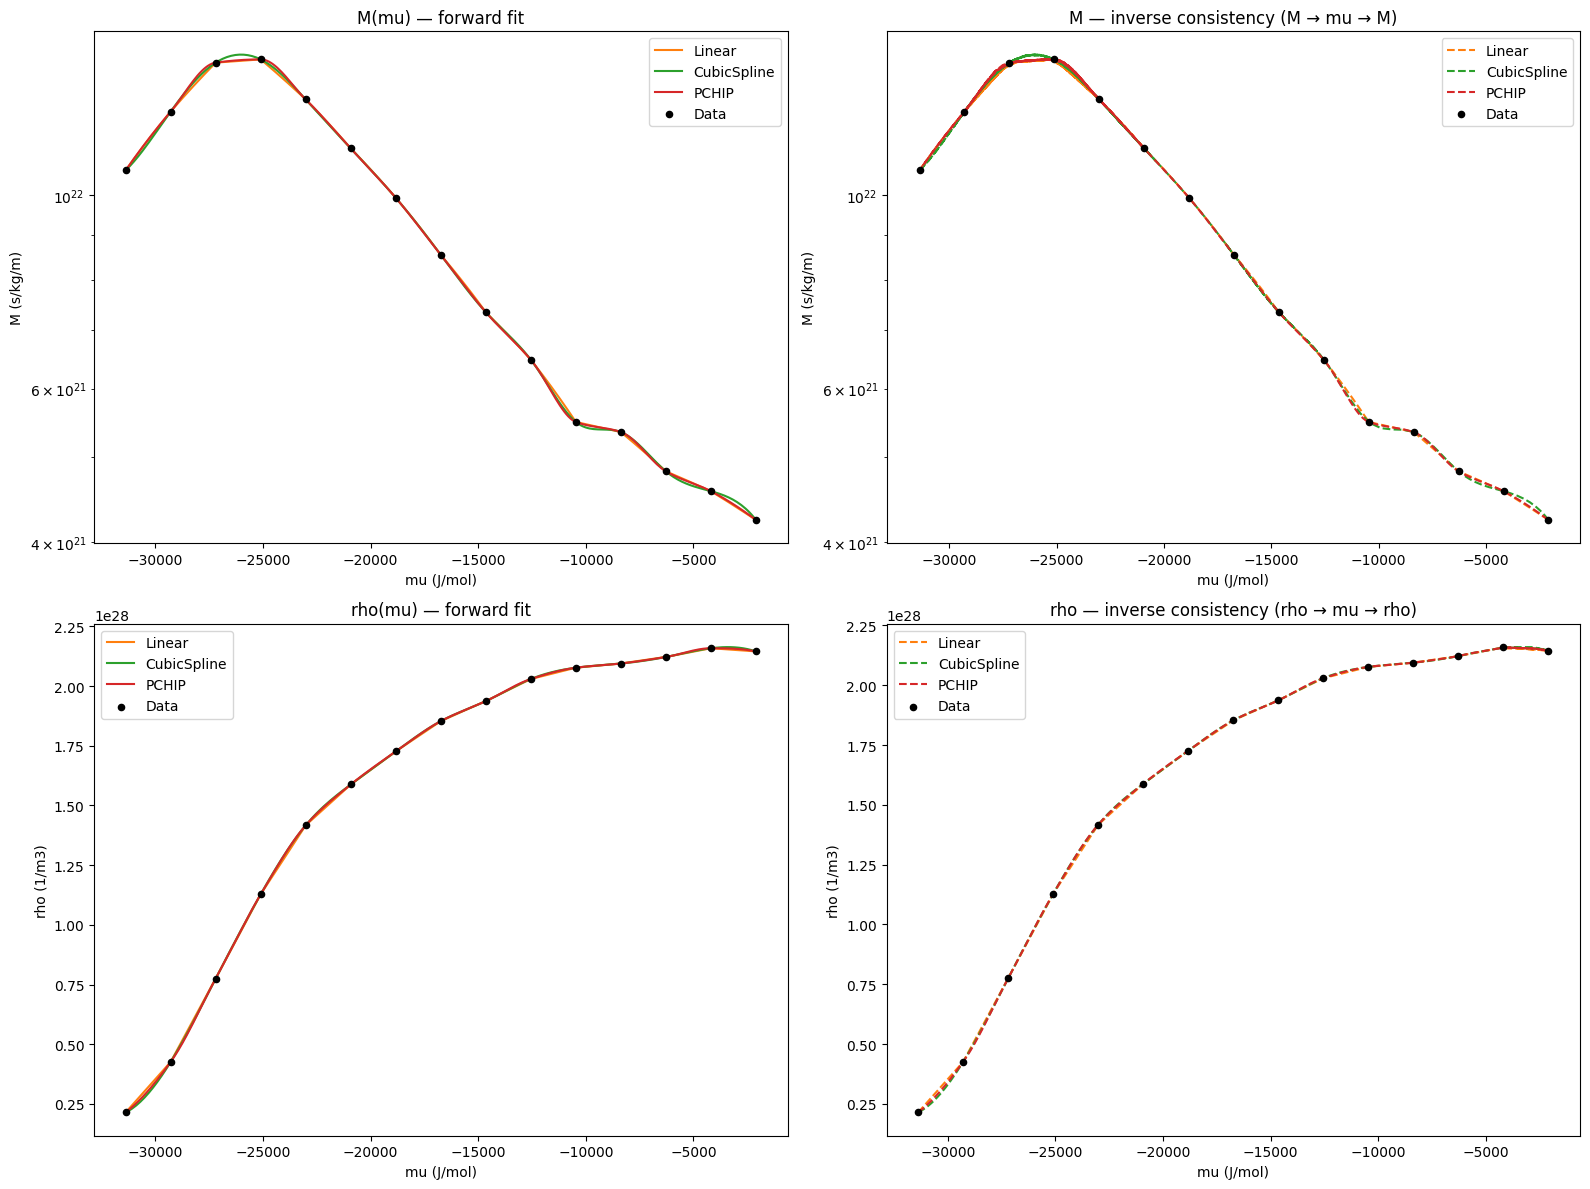

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline, PchipInterpolator

# Define some constants
volume = 4e-9 * 4e-9 * 2e-9 # m3
area = 4e-9 * 2e-9 # m2
m = 40e-3 # mass particle in kg/mol
Na = 6.022e23 # Avogadro
kcal_to_j = 4184.0 # Convert factor
f0_real = 0.01 # force applied on each particle kcal/mol/A
f0_SI = f0_real * kcal_to_j * 1e10 / Na # N

# Load MD data
md_data = np.loadtxt("MD/number_and_v_vs_mu.dat")
mu_real, number, v_real = md_data.T # kcal/mol, 0, A/fs

# Quantities in SI units
mu_SI = mu_real * kcal_to_j
v_SI = v_real * 1e-10/1e-15
rho_SI = number/volume # m-3
total_force = rho_SI * f0_SI * volume # N
total_flux = rho_SI * v_SI * area # 1 / s
M_SI = total_flux / total_force # transport coefficient in 1/s/N = s / kg / m

# ── Interpolation methods ──────────────────────────────────────────────────────
interp_methods = {
    "Linear":       interp1d,
    "CubicSpline":  CubicSpline,
    "PCHIP":        PchipInterpolator,
}

# Build forward and inverse interpolators for both M and rho
# Inverse works by swapping x/y (valid because both M and rho are monotone in mu)
interpolators = {}
for name, method in interp_methods.items():
    # Sort by x for inverse interpolators (required by CubicSpline/PCHIP)
    idx_M   = np.argsort(M_SI)
    idx_rho = np.argsort(rho_SI)

    interpolators[name] = {
        "M_fwd":   method(mu_SI,          M_SI),
        "M_inv":   method(M_SI[idx_M],    mu_SI[idx_M]),
        "rho_fwd": method(mu_SI,          rho_SI),
        "rho_inv": method(rho_SI[idx_rho], mu_SI[idx_rho]),
    }

# Grids (stay within data range for interpolation)
mu_grid  = np.linspace(mu_SI.min(),  mu_SI.max(),  300)
M_grid   = np.linspace(M_SI.min(),   M_SI.max(),   300)
rho_grid = np.linspace(rho_SI.min(), rho_SI.max(), 300)

# ── Consistency check ──────────────────────────────────────────────────────────
print(f"{'Method':<15} {'M round-trip max err':>22} {'rho round-trip max err':>24}")
print("-" * 65)
for name, interps in interpolators.items():
    # M: mu_grid -> M -> mu -> M (round trip)
    M_fwd      = interps["M_fwd"](mu_grid)
    mu_from_M  = interps["M_inv"](M_fwd)
    M_back     = interps["M_fwd"](mu_from_M)
    err_M      = np.max(np.abs(M_back - M_fwd) / M_fwd)

    # rho: mu_grid -> rho -> mu -> rho (round trip)
    rho_fwd      = interps["rho_fwd"](mu_grid)
    mu_from_rho  = interps["rho_inv"](rho_fwd)
    rho_back     = interps["rho_fwd"](mu_from_rho)
    err_rho      = np.max(np.abs(rho_back - rho_fwd) / rho_fwd)

    print(f"{name:<15} {err_M:>22.2e} {err_rho:>24.2e}")

# ── Plots ──────────────────────────────────────────────────────────────────────
colors = {"Linear": "tab:orange", "CubicSpline": "tab:green", "PCHIP": "tab:red"}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for name, interps in interpolators.items():
    col = colors[name]

    M_fwd       = interps["M_fwd"](mu_grid)
    mu_from_M   = interps["M_inv"](M_grid)
    M_back      = interps["M_fwd"](mu_from_M)

    rho_fwd     = interps["rho_fwd"](mu_grid)
    mu_from_rho = interps["rho_inv"](rho_grid)
    rho_back    = interps["rho_fwd"](mu_from_rho)

    # Top-left: M forward
    axes[0, 0].plot(mu_grid, M_fwd, color=col, label=name)

    # Top-right: M back-and-forth
    axes[0, 1].plot(mu_from_M, M_back, "--", color=col, label=name)

    # Bottom-left: rho forward
    axes[1, 0].plot(mu_grid, rho_fwd, color=col, label=name)

    # Bottom-right: rho back-and-forth
    axes[1, 1].plot(mu_from_rho, rho_back, "--", color=col, label=name)

# Scatter data on all panels
for ax in axes[0]:
    ax.scatter(mu_SI, M_SI, s=20, color="black", zorder=5, label="Data")
    ax.set_xlabel("mu (J/mol)")
    ax.set_ylabel("M (s/kg/m)")
    ax.set_yscale("log")
    ax.legend()

for ax in axes[1]:
    ax.scatter(mu_SI, rho_SI, s=20, color="black", zorder=5, label="Data")
    ax.set_xlabel("mu (J/mol)")
    ax.set_ylabel("rho (1/m3)")
    ax.legend()

axes[0, 0].set_title("M(mu) — forward fit")
axes[0, 1].set_title("M — inverse consistency (M → mu → M)")
axes[1, 0].set_title("rho(mu) — forward fit")
axes[1, 1].set_title("rho — inverse consistency (rho → mu → rho)")

plt.tight_layout()
plt.show()

cs_rho = CubicSpline(mu_SI, rho_SI)
cs_M   = CubicSpline(mu_SI, M_SI)

# cs.c has shape (4, n-1): rows are coefficients for x^3, x^2, x^1, x^0
# on each interval [x_i, x_{i+1}], polynomial is evaluated at (x - x_i)

np.savetxt("spline_rho_vs_mu.txt", np.column_stack([
    cs_rho.x[:-1], cs_rho.x[1:],          # interval [x_i, x_{i+1}]
    cs_rho.c[0], cs_rho.c[1], cs_rho.c[2], cs_rho.c[3]  # c3, c2, c1, c0
]), header="x_left x_right c3 c2 c1 c0")

In [26]:
mu_SI, rho_SI

(array([-31380., -29288., -27196., -25104., -23012., -20920., -18828.,
        -16736., -14644., -12552., -10460.,  -8368.,  -6276.,  -4184.,
         -2092.]),
 array([2.14292953e+27, 4.25968320e+27, 7.74968070e+27, 1.12824786e+28,
        1.41704381e+28, 1.58781514e+28, 1.72629109e+28, 1.85312222e+28,
        1.93674062e+28, 2.02943414e+28, 2.07675478e+28, 2.09429698e+28,
        2.12159249e+28, 2.15824564e+28, 2.14501472e+28]))

In [13]:
coeffs_M_vs_mu

array([2.10160623e+09, 1.00697726e+14, 9.39149615e+17, 6.60207957e+21])